# E-Commerce Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Loading The Dataset:

data = pd.read_csv("Superstore.csv", encoding='latin1')

## Data Understanding

In [3]:
# Analyisng How many rows and columns is in our dataset.

print(f"Total rows: {data.shape[0]} \nTotal Columns: {data.shape[1]}")

Total rows: 9994 
Total Columns: 21


In [4]:
# Brief Summary of our DataFrame:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## Data Cleaning and Preprocessing

In [5]:
# Checking for any duplicated values:

print(f"duplicated Values: {data.duplicated().sum()}")

duplicated Values: 0


In [6]:
# Checking for Missing Valus:

print(f"Missing Values: \n{data.isna().sum()}")

Missing Values: 
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [7]:
# Converting dtype of date columns: (dtype: object) -> (dtype: datetime) 

data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

In [8]:
# Adding a new column "Shipping Days" to analyse how many days it took to ship goods:

data["Shipping Days"] = (data['Ship Date'] - data['Order Date']).dt.days

## Business Overview

In [9]:
total_sales = data['Sales'].sum()
total_profit = data['Profit'].sum()
total_orders = data['Order ID'].nunique()
total_customers = data['Customer ID'].nunique()

print(f"Total Sales: {total_sales}")
print(f"Total Profit: {total_profit}")
print(f"Total Orders: {total_orders}")
print(f"Total Customers: {total_customers}")

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Orders: 5009
Total Customers: 793


## Sales Trend Over Time [Time Series Analysis]

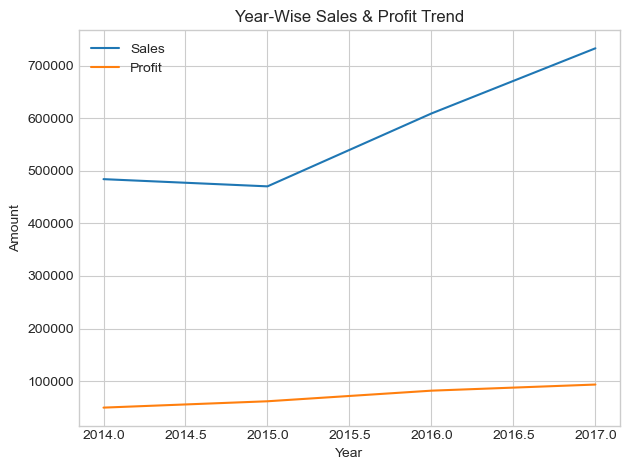

In [32]:
# Year-Wise Sales and Profit Analysis:

data["Year"]= data['Order Date'].dt.year
yearly_sales = data.groupby("Year")[['Sales', 'Profit']].sum()

yearly_sales.plot(kind='line')
plt.title("Year-Wise Sales & Profit Trend")
plt.xlabel("Year")
plt.ylabel("Amount")

### Observations:

The company experienced stable and serious growth after 2015, with highest sales in the year 2017 (~730k).

There is a consistent rise in profit over the years, which suggests effective cost management alongside revenue exapnasion.

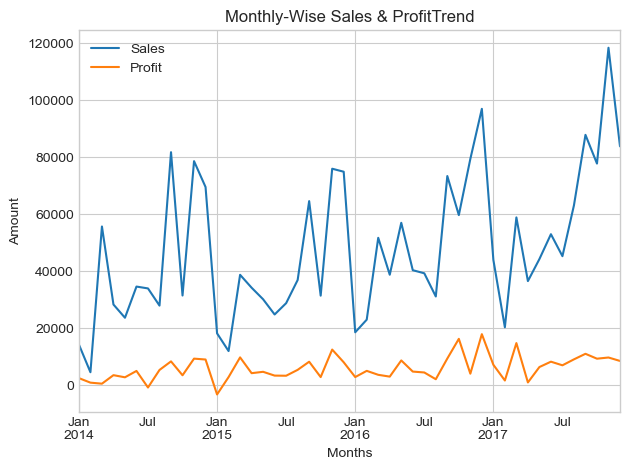

In [33]:
# Monthly-Wise Sales and Profit Analysis:

data["Month Year"] = data['Order Date'].dt.to_period('M')
monthly_sales = data.groupby("Month Year")[['Sales','Profit']].sum()
monthly_sales.plot(kind='line')
plt.title("Monthly-Wise Sales & ProfitTrend")
plt.xlabel("Months")
plt.ylabel("Amount")

### Observations:

We can cleary see that the sales spikes up at the 4th quarter of each year, likely by holdiay or festive season.

The profit margin shows the same trend as sales, which suggests company should strategically increase inventory and marketing efforts during high-demand months.

## Category and Product Analysis

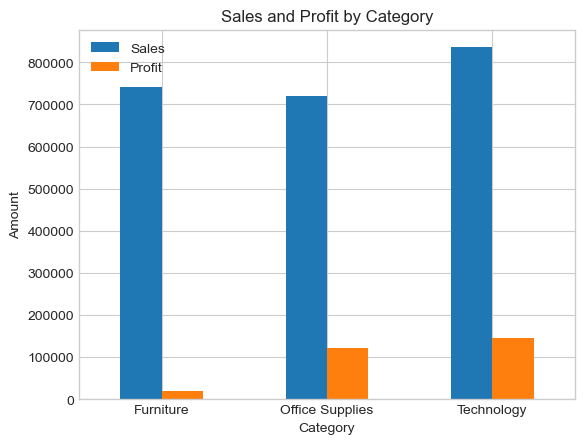

In [12]:
# Category-Wise Sales and Profit Analysis

category_analysis = data.groupby("Category")[['Sales','Profit']].sum()
category_analysis.plot(kind='bar')
plt.title("Sales and Profit by Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

### Observations:

The Technology category generates the highest profit despite not always having the highest sales volume, indicating strong margins.

Furniture, while contributing significantly to total revenue, delivers comparatively lower profitability, suggesting higher costs or heavy discounting.

Office Supplies shows stable performance with balanced sales and profit contribution. 

<Figure size 1000x500 with 0 Axes>

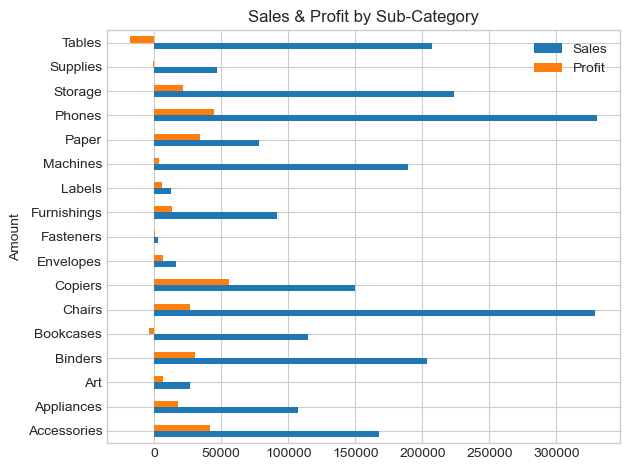

In [36]:
# Sub-Category Analysis:

sub_cat = data.groupby("Sub-Category")[['Sales', 'Profit']].sum()
plt.figure(figsize=(10,5))
sub_cat.plot(kind='barh')
plt.title("Sales & Profit by Sub-Category")
plt.ylabel("Amount")

plt.tight_layout()
plt.savefig("category.png", dpi=300, bbox_inches='tight')
plt.show()

### Observations:

Despite a good profitability, certain sub-categories such as 'Tables', 'Supplies', 'Bookcases' shows losses, indicatibg prices or discount strategy inefficiences.

## Regional Analysis

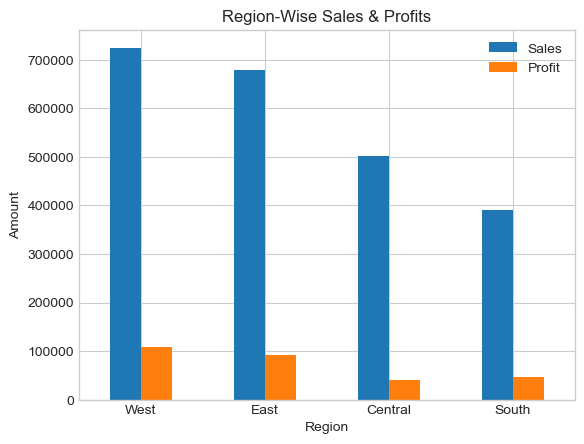

In [14]:
# Region-wise Sales & Profit:

regional_analysis = data.groupby("Region")[['Sales','Profit']].sum().sort_values(by='Sales', ascending=False)
regional_analysis.plot(kind='bar')
plt.title("Region-Wise Sales & Profits")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

### Observations:

The West region contributes the highest revenue and profitability, indicating strong market presence and demand.

The South region generates comparatively lower revenue and profit, suggesting potential for market expansion or improved sales strategies.

While some regions generate high sales, profitability varies, indicating regional differences in discounting or operational costs.

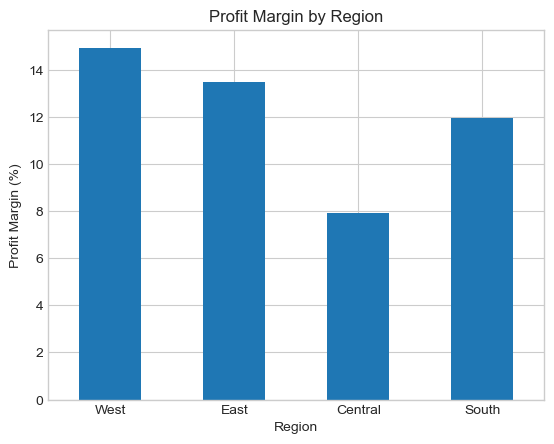

In [15]:
# Profit Mrgin by region:

regional_analysis["Profit Margin %"] = (regional_analysis['Profit'] / regional_analysis['Sales'])*100
regional_analysis['Profit Margin %'].plot(kind='bar')
plt.title("Profit Margin by Region")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.show()

### Observations:

Although west region has highest sales their profit margin is lower as compare to south region with less sales but high profit margin

## Discount vs Profit Relationship

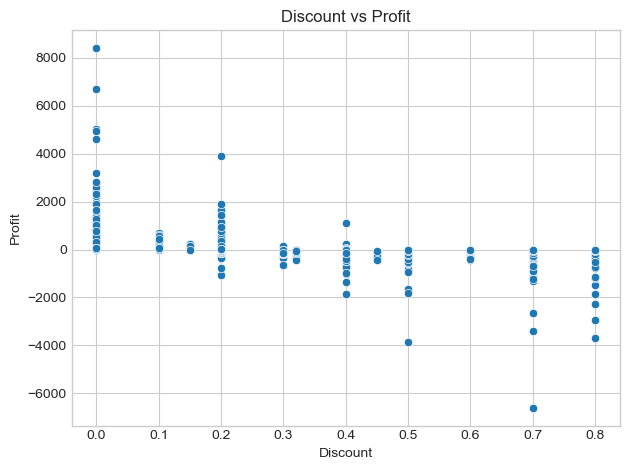

In [38]:
sns.scatterplot(data, x='Discount', y='Profit')
plt.title("Discount vs Profit")
plt.tight_layout()
plt.savefig("dvp.png", dpi=300, bbox_inches='tight')
plt.show()

In [17]:
data[['Discount','Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


### Observations:

The analysis reveals a negative relationship between discount and profit. Higher discount levels are associated with less profits, with several high-discount transactions resulting in losses.

This suggests that aggressive discounting strategies may be increasing revenue volume but eroding profit margins.

## Customer Analysis

In [18]:
print(f"Total Orders: {total_orders}")
print(f"Total Customers: {total_customers}")

Total Orders: 5009
Total Customers: 793


In [19]:
average_order_value = data['Sales'].sum()/total_orders
print(f"Average Order Value: {average_order_value}")

Average Order Value: 458.6146656618087


### Observations:

The company serves 793 unique customers with an average order value of (~458$), indicating moderate transaction size per order

In [20]:
# Top 10 customers by sales:

top_customers = data.groupby("Customer Name")['Sales'].sum().sort_values(ascending=False).head(10)
top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

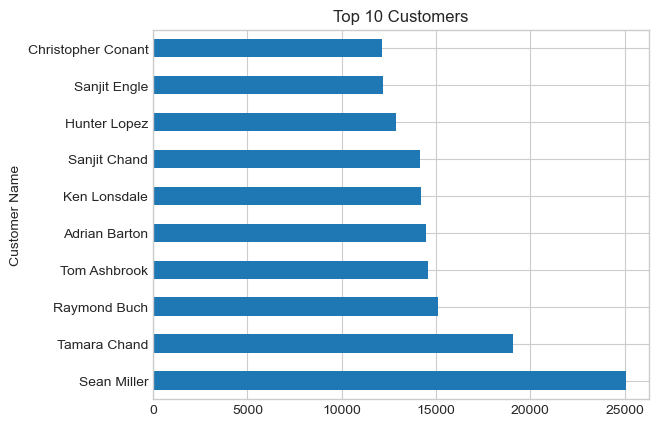

In [21]:
top_customers.plot(kind='barh')
plt.title("Top 10 Customers")
plt.show()

### Observations:

Revenue distribution shows that a small group of customers contributes a disproportionately high share of total sales, indicating potential dependency risk.

In [22]:
# Profit By Customer:

top_profit_customers = data.groupby("Customer Name")['Profit'].sum().sort_values(ascending = False).head(10)
top_profit_customers

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64

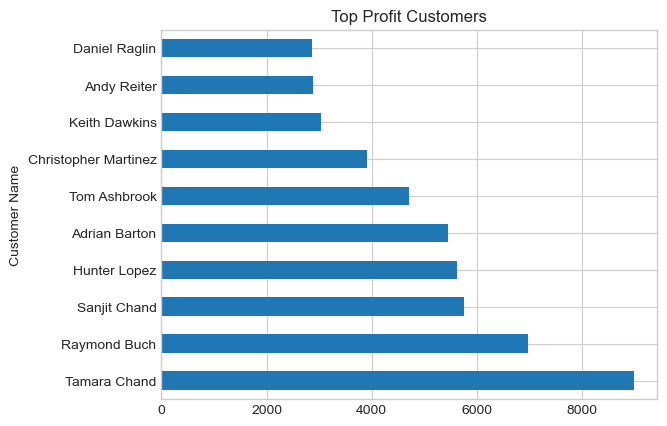

In [23]:
top_profit_customers.plot(kind='barh')
plt.title("Top Profit Customers")
plt.show()

### Observations:

we can clearly see Sean Miller who is providing highest sales, but doesn't provide as much profit

In [24]:
# Repeat Customer Analysis:

customer_orders = data.groupby("Customer ID")['Order ID'].nunique()
repeated_customer = customer_orders[customer_orders > 1].count()
one_time_customer = customer_orders[customer_orders == 1].count()

print(f"Repeated Customers: {repeated_customer}")
print(f"One Time Customers: {one_time_customer}")

Repeated Customers: 781
One Time Customers: 12


### Observations:

A significant portion of customers are one-time buyers, suggesting potential opportunities to improve customer retention strategies.

## Shipping Data Analysis

In [25]:
data['Shipping Days'].describe()

count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

### Observations:

The average shipping duration is ~4 days, with minimum of 0 days to maximum of 7 days

In [26]:
ship_mode_analysis = data.groupby("Ship Mode")['Shipping Days'].mean().sort_values()
ship_mode_analysis

Ship Mode
Same Day          0.044199
First Class       2.182705
Second Class      3.238046
Standard Class    5.006535
Name: Shipping Days, dtype: float64

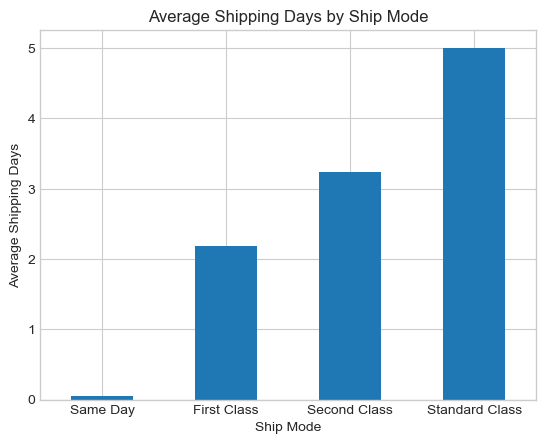

In [27]:
ship_mode_analysis.plot(kind='bar')
plt.title("Average Shipping Days by Ship Mode")
plt.ylabel("Average Shipping Days")
plt.xticks(rotation=0)
plt.show()

In [28]:
data.groupby("Ship Mode")["Profit"].mean().sort_values(ascending=False)

Ship Mode
First Class       31.839948
Second Class      29.535545
Same Day          29.266591
Standard Class    27.494770
Name: Profit, dtype: float64

### Observations:

Same Day shipping provides fastest delivery time but their profit is not as good, as the first class profit margin and delivery time, while the standard class has the longest time duration with least average profit 

In [29]:
# Region Wise Shipping Analysis:

data.groupby("Region")['Shipping Days'].mean().sort_values(ascending=False)

Region
Central    4.058115
South      3.958025
West       3.929753
East       3.908708
Name: Shipping Days, dtype: float64

### Observations:

The Central region shows slightly longer delivery durations, indicating potential logistics inefficiencies.

## FINAL BUSINESS RECOMMENDATIONS

1. The Technology category generates the highest profit for the company. The business should focus more on promoting and expanding this category since it provides strong margins.

2. The analysis shows that higher discounts reduce profit significantly. Many high-discount transactions result in low or negative profit, so company should focus targeted discounts and use seasonal promotions strategically.

3. Some regions generate lower sales and profit compared to others. The company can improve marketing efforts and optimize logistics and supply chain operations.

4. A noticeable number of customers are one-time buyers. The company should offer personalized recommendations.

5. Standard shipping takes longer compared to other shipping modes. The company can ensure delivery speed matches customer expectations

### Overall, the business is growing steadily and remains profitable. However, optimizing discount strategies, improving customer retention, and focusing on high-margin categories can significantly enhance long-term profitability.